# Notebook 1 — Introduction to PyTorch & CIFAR-10

This notebook walks through:
1. Loading and visualising CIFAR-10
2. Defining the `CIFAR10Net` model
3. A **mini training loop** (5 epochs, CPU-friendly) so you can verify everything works
4. Saving a checkpoint

> **Workshop tip:** Run cells top-to-bottom. Each section is self-contained.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import torch
import matplotlib.pyplot as plt
import numpy as np

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {device}')

Matplotlib is building the font cache; this may take a moment.


PyTorch version : 2.8.0
CUDA available  : False
Using device    : cpu


## 1. Load CIFAR-10

In [2]:
from utils import get_dataloaders
from pathlib import Path

train_loader, val_loader = get_dataloaders(
    batch_size=64,
    num_workers=2,
    data_dir=Path('../datasets')
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

100%|█████████████████████████████████████████████████████| 170M/170M [00:04<00:00, 39.4MB/s]


Train batches : 781
Val batches   : 79


## 2. Visualise a batch

/Users/santhoshbajjuri/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


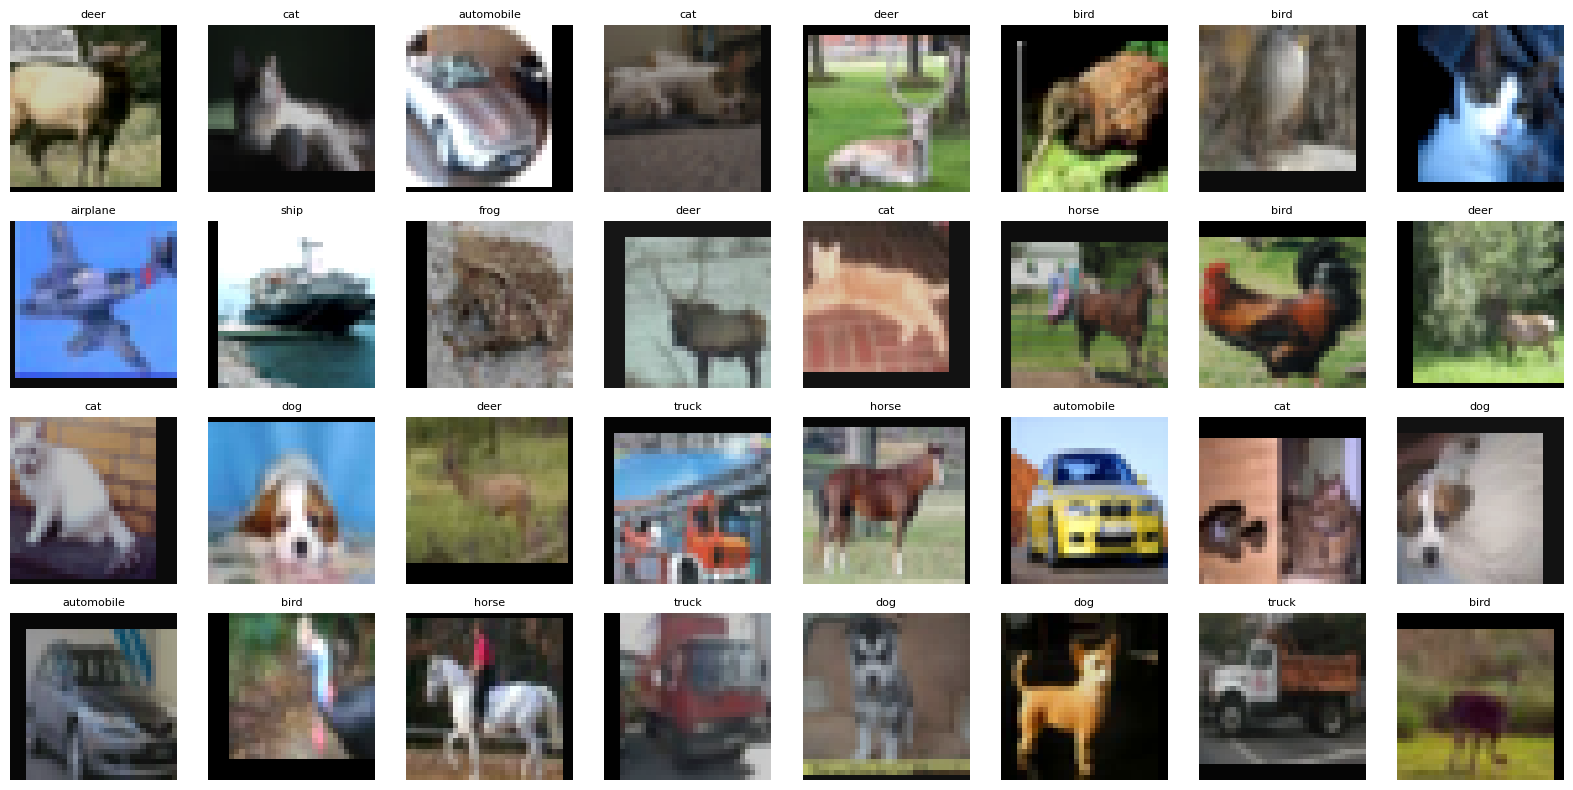

In [3]:
from model import CIFAR10Net
from utils import CIFAR10_MEAN, CIFAR10_STD

CLASS_NAMES = CIFAR10Net.CLASS_NAMES

def denormalize(img_tensor):
    mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR10_STD).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for ax, img, lbl in zip(axes.flatten(), images[:32], labels[:32]):
    ax.imshow(denormalize(img).permute(1,2,0).numpy())
    ax.set_title(CLASS_NAMES[lbl], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Inspect the model

In [4]:
from model import build_model

model = build_model().to(device)
print(model)
print(f'\nTotal parameters: {model.num_parameters:,}')

# Quick sanity-check forward pass
dummy = torch.randn(8, 3, 32, 32).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}  (should be [8, 10])')

CIFAR10Net(
  (stem): ConvBlock(
    (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (stage1): Sequential(
    (0): ResidualBlock(
      (conv1): ConvBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv2): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): ConvBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv2

## 4. Mini training loop (5 epochs)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

EPOCHS = 5

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = OneCycleLR(optimizer, max_lr=0.1,
                       steps_per_epoch=len(train_loader),
                       epochs=EPOCHS, pct_start=0.3)

train_losses, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    running_loss = correct = total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
    val_acc = correct / len(val_loader.dataset) * 100

    epoch_loss = running_loss / total
    train_losses.append(epoch_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch:02d}/{EPOCHS}  loss={epoch_loss:.4f}  val_acc={val_acc:.2f}%')

## 5. Plot training curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_accs, marker='o', color='darkorange')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save checkpoint

In [ ]:
from utils import save_checkpoint

ckpt_path = '../datasets/intro_checkpoint.pth'
save_checkpoint(
    {'epoch': EPOCHS, 'model_state_dict': model.state_dict(), 'val_acc': val_accs[-1]},
    ckpt_path
)
print(f'Checkpoint saved to {ckpt_path}')

---
**Next:** Open `02_train_sagemaker.ipynb` to train the full model on a SageMaker GPU instance.